# Pursuit — offline analysis notebook

Segal §2.4 / §17 ("analysis notebook with graphs"). Everything below is drawn from files
that are **in the tracked set**, so this notebook runs end to end on a fresh clone with
**no network, no API key and no training run**. It reads nothing from `logs/` (gitignored)
and nothing from `game_artifacts/` (deliberately untracked, D7-19) — both would be empty
on a clean checkout and the notebook would silently plot nothing.

**Read the numbers with these limits in front of you.**

* **No league game has been played.** Nothing here is a competitive result. The
  opponents in the sensitivity sweep are the two hand-written archetypes
  (`strategy/naive.py`), not another team.
* **The token figures rest on one live game** — 23 provider calls against
  `claude-haiku-4-5-20251001` on 2026-08-09. n = 1.
* **The mail channel has never delivered a message** and the games-played counter is
  deliberately unset (rule 38). Neither appears here.

Regenerate the two inputs this notebook does not ship with:

```
uv run python scripts/sensitivity_sweep.py
uv run python scripts/token_cost_report.py
```

Companion documents: `docs/SENSITIVITY.md`, `docs/TOKEN-COST.md`,
`docs/phases/phase-3/ENGINEERING-LOG.md`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

# Walk up to the repository root, so the notebook runs from any working directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

INPUTS = {
    'selfplay_curve': 'artifacts/run2/curve.json',
    'evolution_curve': 'artifacts/run2_es/curve.json',
    'sensitivity': 'artifacts/sensitivity/sweep.json',
    'token_cost': 'artifacts/token_cost/token_cost.json',
}

# Two assertions, and they are the point of the cell. The first makes a missing input a
# LOUD failure rather than an empty axis that still looks like evidence. The second pins
# the offline property in the notebook itself, not only in the test that checks it.
FORBIDDEN = ('logs/', 'game_artifacts/', 'http://', 'https://')
missing = [path for path in INPUTS.values() if not (ROOT / path).is_file()]
assert not missing, f'missing inputs: {missing} — run the two scripts named above'
assert not [p for p in INPUTS.values() if p.startswith(FORBIDDEN)], INPUTS

data = {
    name: json.loads((ROOT / path).read_text(encoding='utf-8'))
    for name, path in INPUTS.items()
}
print(f'{len(data)} tracked inputs loaded from {ROOT.name}/')
for name, path in INPUTS.items():
    print(f'  {name:<16} {path}')

4 tracked inputs loaded from final_project/
  selfplay_curve   artifacts/run2/curve.json
  evolution_curve  artifacts/run2_es/curve.json
  sensitivity      artifacts/sensitivity/sweep.json
  token_cost       artifacts/token_cost/token_cost.json


## 1. What Phase 3 actually learned

Two runs, both kept. The left panel is the outcome-regression self-play run whose vector
ships in `config/*/weights.json`. The right panel is the `(1+λ)`-ES run, kept as a
**documented negative result** (`docs/phases/phase-3/ENGINEERING-LOG.md`, Act 5) rather
than deleted — the same reason run 1's flawed control was written up instead of dropped.

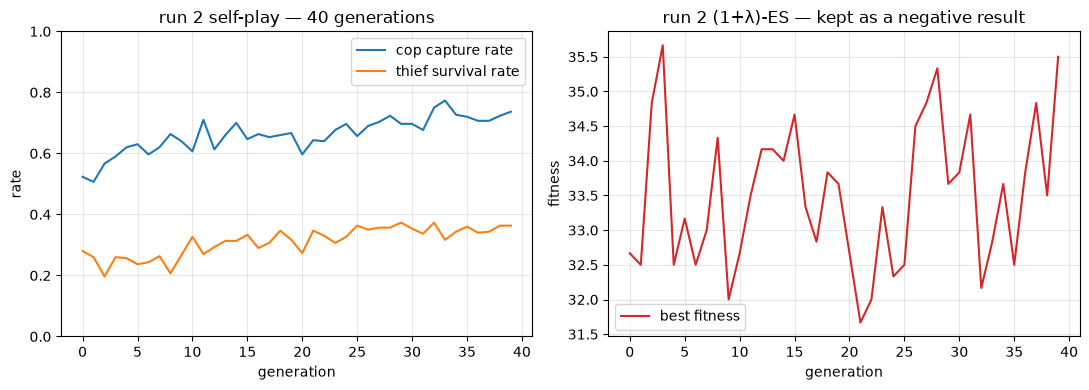

In [2]:
selfplay, evolution = data['selfplay_curve'], data['evolution_curve']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
generations = [row['generation'] for row in selfplay]
axes[0].plot(generations, [row['cop_capture_rate'] for row in selfplay], label='cop capture rate')
axes[0].plot(generations, [row['thief_survival_rate'] for row in selfplay], label='thief survival rate')
axes[0].set_title(f'run 2 self-play — {len(selfplay)} generations')
axes[0].set_xlabel('generation')
axes[0].set_ylabel('rate')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    [row['generation'] for row in evolution],
    [row['best_fitness'] for row in evolution],
    color='tab:red', label='best fitness',
)
axes[1].set_title('run 2 (1+λ)-ES — kept as a negative result')
axes[1].set_xlabel('generation')
axes[1].set_ylabel('fitness')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 2. Which parameters actually move the outcome

One-factor-at-a-time from the shipped configuration. Only parameters whose
`docs/PARAMETERS.md` status is `minimum` (swept **upward only**) or `negotiable`, plus two
labelled engineering defaults; `scripts/sensitivity_status.py`'s `refuse_fixed` fails if
a **fixed** parameter ever reaches the grid.

A bar is **red** only when its 95% Wilson interval does not overlap the baseline's — the
conservative separability test `training/arena.compare` already uses. A blue bar is a
difference the sample cannot distinguish from noise, and most of them are.

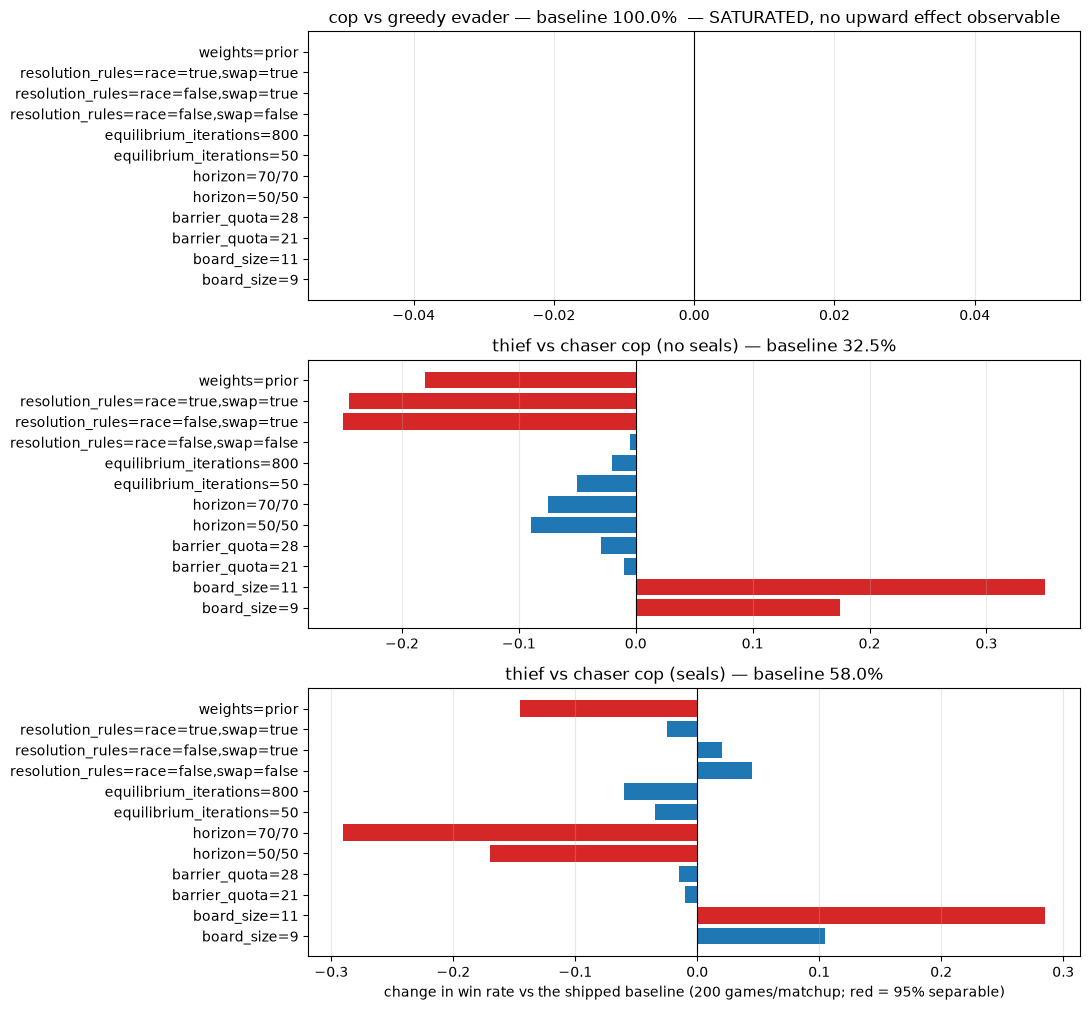

In [3]:
sweep = data['sensitivity']
base = next(cell for cell in sweep['cells'] if cell.get('is_baseline'))
cells = [cell for cell in sweep['cells'] if not cell.get('is_baseline')]
labels = list(base['matchups'])


def separable(one, other):
    """Non-overlapping 95% Wilson intervals — arena.compare's rule."""
    return one['ci_low'] > other['ci_high'] or one['ci_high'] < other['ci_low']


fig, axes = plt.subplots(len(labels), 1, figsize=(11, 3.4 * len(labels)), squeeze=False)
for row, label in enumerate(labels):
    axis, reference = axes[row][0], base['matchups'][label]
    names = [f"{cell['knob']}={cell['value']}" for cell in cells]
    deltas = [cell['matchups'][label]['rate'] - reference['rate'] for cell in cells]
    colours = [
        'tab:red' if separable(cell['matchups'][label], reference) else 'tab:blue'
        for cell in cells
    ]
    axis.barh(names, deltas, color=colours)
    axis.axvline(0, color='black', linewidth=0.8)
    saturated = '  — SATURATED, no upward effect observable' if reference['rate'] >= 1.0 else ''
    axis.set_title(f"{label} — baseline {reference['rate']:.1%}{saturated}")
    axis.grid(axis='x', alpha=0.3)

axes[-1][0].set_xlabel(
    f"change in win rate vs the shipped baseline "
    f"({sweep['games_per_matchup']} games/matchup; red = 95% separable)"
)
fig.tight_layout()
plt.show()

## 3. Where the tokens go, and when the budget runs out

Left: the one live game's spend, split input against output. Right: that game's per-turn
rate extrapolated to full-length games against the configured series budget and the two
`DegradeLevel` thresholds.

**The right panel is an extrapolation, not a measurement.** The live game ended in a
capture at turn 14 of a 35-turn ceiling, and it assumes a flat per-turn rate that one game
cannot demonstrate.

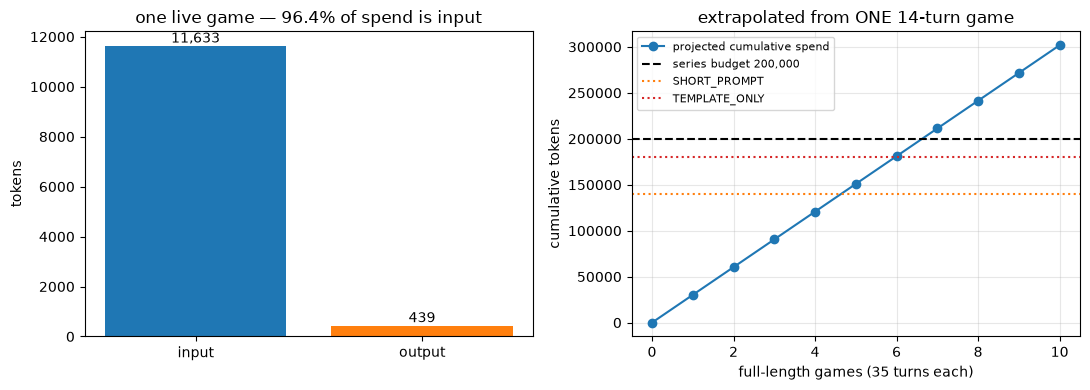

6.63 full-length games fit the 200,000-token budget.
The FIXED maximum of 10 games per team (Table 18 row 5) would need 301,800 — it does NOT fit.


In [4]:
token = data['token_cost']
live, projection, config = token['live'], token['projection'], token['config']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
split = [live['input_tokens'], live['output_tokens']]
axes[0].bar(['input', 'output'], split, color=['tab:blue', 'tab:orange'])
axes[0].set_title(f"one live game — {live['input_share']:.1%} of spend is input")
axes[0].set_ylabel('tokens')
for index, value in enumerate(split):
    axes[0].text(index, value, f'{value:,}', ha='center', va='bottom')

games = list(range(projection['max_games_per_team'] + 1))
axes[1].plot(games, [g * projection['tokens_per_full_game'] for g in games],
             marker='o', label='projected cumulative spend')
axes[1].axhline(config['token_budget_per_series'], color='black', linestyle='--',
                label=f"series budget {config['token_budget_per_series']:,}")
axes[1].axhline(config['short_prompt_threshold_tokens'], color='tab:orange', linestyle=':',
                label='SHORT_PROMPT')
axes[1].axhline(config['template_only_threshold_tokens'], color='tab:red', linestyle=':',
                label='TEMPLATE_ONLY')
axes[1].set_xlabel(f"full-length games ({config['move_ceiling']} turns each)")
axes[1].set_ylabel('cumulative tokens')
axes[1].set_title('extrapolated from ONE 14-turn game')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

print(
    f"{projection['games_within_budget']:.2f} full-length games fit the "
    f"{config['token_budget_per_series']:,}-token budget.\n"
    f"The FIXED maximum of {projection['max_games_per_team']} games per team "
    f"(Table 18 row 5) would need {projection['tokens_for_max_games']:,.0f} — "
    f"{'it does NOT fit' if not projection['max_games_fits_budget'] else 'it fits'}."
)

## 4. What these figures do not show

* **No opponent modelling.** The sweep's opponents are two fixed archetypes. A knob that
  helps against a chaser may hurt against a team that seals differently, and this project
  has no league data to check that against.
* **The cop matchup is saturated.** `cop vs greedy evader` is at 100% at the baseline, so
  every knob reads `+0.0%` there. That is a ceiling, not evidence that nothing matters.
* **n = 1 for every token figure.** A second live game would be the single most valuable
  measurement this project could add.
* **The Phase-4 belief on/off comparison is not plotted.** `gate4_measurement_mocked.json`
  records it over **3 seeds per arm**, which is too small to draw, and the honest thing is
  to say so rather than render a two-bar chart that looks like a result.